# Inspect Data

Below are code snippets for common tasks on OPS (Optical Pooled Screening) data,
using the [OPS Data Standard v0.1.0](../../ops-schema/ops-schema-main/standards/ops/0.1.0/schema.md).
Examples run end-to-end on the Brieflow test collection bundled under
`ops-data/cxs_test_data/`. Add an example you'd like to share by opening an
issue and including "Example:" in the title.

## The OPS data model

OPS datasets are organized in a four-level hierarchy:

```
Collection                      # one per submission; groups experiments from a single publication
└── Experiment (Screen)         # one or more per collection
    └── Visualization (Subset)  # one or more per experiment
```

Per-experiment artifacts:

- `cell_data.parquet` — one row per cell, with morphological feature columns
- `{screen_name}.zarr` — primary OME-NGFF HCS image store

Per-visualization artifacts:

- `aggregated_data.h5ad` — `(n_perturbations, n_features)` AnnData with effect
  sizes in `.X`, significance in `.layers["neg_log10_fdr"]`, and a 2D embedding
  in `.obsm`
- `examples.zarr` — representative single-cell image crops

The snippets below operate on the per-cell and per-perturbation tables. The
image stores are out of scope for this tutorial.

## Run this notebook in the browser

This notebook streams an OPS collection directly from the public S3 bucket —
nothing is downloaded to local disk while you work. Every cell below reads
exactly the bytes it needs from S3, which lets you explore a collection from
a hosted Jupyter environment (Google Colab, JupyterHub, Binder) without
provisioning storage.

If you decide you want a local copy after exploring, the
[**Putting it together**](#putting-it-together-pulling-a-local-copy) section
at the end shows how to grab the whole collection with the
[`biohub-data-cli`](https://github.com/chanzuckerberg/ops-schema/blob/main/docs/cli/index.md)
in a single command.


## Setup

In [ ]:
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import fsspec
import s3fs

# S3 prefix for the collection. The OPS public bucket is anonymously readable —
# no AWS credentials needed.
COLLECTION = "s3://<ops-public-bucket>/brieflow-test-collection"
S3_OPTS = {"anon": True}

print("Streaming from:", COLLECTION)


## Inspect the collection in S3

Listing the S3 prefix shows which schema artifacts are present in the
collection without downloading any of them.


In [2]:
fs = s3fs.S3FileSystem(anon=True)
for entry in fs.ls(COLLECTION, detail=True):
    name = entry["name"].rsplit("/", 1)[-1]
    size_mb = entry["size"] / 1e6
    print(f"{name:30s}  {size_mb:>8.2f} MB")


aggregated_data.h5ad                0.75 MB
cell_data.parquet                  12.11 MB
collection_metadata.yaml            0.00 MB


## Load the collection metadata

`collection_metadata.yaml` holds publication-level metadata (title, DOI,
contact) shared by every experiment in the collection.

In [3]:
with fsspec.open(f"{COLLECTION}/collection_metadata.yaml", "r", anon=True) as fh:
    collection_metadata = yaml.safe_load(fh)
collection_metadata


{'collection': {'title': 'Brieflow Test Collection', 'publication_doi': None}}

## Load the per-cell feature table

`cell_data.parquet` has one row per cell. Required identifier columns include
`cell_uid`, `plate`, `well_row`, `well_col`, `tile`, `x`, `y`, `barcode`, and
`perturbation_id`. Additional feature columns may follow; their names are not
constrained so different platforms (CellProfiler, deep-learning models) can be
mixed.

In [4]:
cells = pd.read_parquet(f"{COLLECTION}/cell_data.parquet", storage_options=S3_OPTS)
print("shape:", cells.shape)
cells.select_dtypes(exclude="number").head()


shape: (1372, 1696)


,cell_uid,well,barcode,perturbation_id,gene_id_0,cell_barcode_1,gene_symbol_1,gene_id_1,mapped_single_gene,well_row,class,is_control,region
0,1_A1_141_686,A1,AACATGCTCCG,NDUFA4,ENSG00000189043,NaN,NaN,NaN,True,A,Interphase,False,1_A1
1,1_A1_141_432,A1,CTCCATCCTGG,DDT,ENSG00000099977,GAAGCTTGGCC,PTPN1,ENSG00000196396,False,A,Interphase,False,1_A1
2,1_A1_141_355,A1,CGGCGTCTAGC,H4C15,ENSG00000270276,NaN,NaN,NaN,True,A,Interphase,False,1_A1
3,1_A1_5_311,A1,ACAAGAAGTAC,DYNLL1,ENSG00000088986,NaN,NaN,NaN,True,A,Interphase,False,1_A1
4,1_A1_5_868,A1,GCGACGAAGCG,RNASEH2C,ENSG00000172922,GTTTCAGAGCT,NaN,NaN,True,A,Interphase,False,1_A1


## Load the per-perturbation aggregated AnnData

`aggregated_data.h5ad` is the visualization-layer artifact: rows are
perturbations, columns are the standardized morphological feature set.
`.X` stores per-perturbation effect sizes; `.layers["neg_log10_fdr"]` stores
significance; `.obsm` stores a 2D embedding for plotting.

In [5]:
# Note: ad.read_h5ad() reads the file-like object into memory in one go, so
# this buffers the whole h5ad before parsing. The aggregated_data.h5ad files
# are typically 10s–100s of MB, well within memory budget.
with fsspec.open(f"{COLLECTION}/aggregated_data.h5ad", "rb", anon=True) as fh:
    agg = ad.read_h5ad(fh)
agg


AnnData object with n_obs × n_vars = 709 × 76
    obs: 'cluster_group_1', 'perturbation_id'
    var: 'feature_name', 'feature_type', 'compartment'
    uns: 'default_embedding', 'neg_log10_fdr_threshold', 'observation_unit', 'schema_version', 'title'
    obsm: 'X_phate'
    layers: 'neg_log10_fdr', 'p_values'

The standardized feature set is partitioned by type and compartment.

In [6]:
print("feature types:", agg.var.feature_type.value_counts().to_dict())
print("compartments :", agg.var.compartment.value_counts().to_dict())
print("default embedding:", agg.uns["default_embedding"])
print("FDR threshold (-log10):", round(float(agg.uns["neg_log10_fdr_threshold"]), 4))

feature types: {'intensity': 56, 'correlation': 12, 'shape': 8}
compartments : {'cell': 38, 'nucleus': 38}
default embedding: X_phate
FDR threshold (-log10): 1.301


## Slice: all cells for one perturbation

Select rows in `cell_data` by `perturbation_id`. This returns every cell that
received an sgRNA mapped to that gene.

In [7]:
pert = "AKIRIN2"
gene_cells = cells[cells.perturbation_id == pert]
gene_cells[["cell_uid", "well", "tile", "class", "is_control"]].head()

,cell_uid,well,tile,class,is_control
271,1_A1_5_653,A1,5,Interphase,False
520,1_A1_5_189,A1,5,Interphase,False
568,1_A1_5_672,A1,5,Interphase,False
1067,1_A1_5_641,A1,5,Interphase,False
1139,1_A1_5_663,A1,5,Interphase,False


## Slice: all non-targeting control cells

Each non-targeting barcode is a separate `perturbation_id` (e.g.
`nontargeting_GAGTTTCTAGT`). The `is_control` boolean column groups them all.

In [8]:
controls = cells[cells.is_control]
print(f"{len(controls)} control cells across {controls.perturbation_id.nunique()} non-targeting barcodes")
controls.perturbation_id.value_counts().head()

39 control cells across 18 non-targeting barcodes


perturbation_id
nontargeting_GAGAACGTGAT    5
nontargeting_GAGTTTCTAGT    5
nontargeting_AAATAATATGC    4
nontargeting_AAGAAGAATTG    3
nontargeting_GGATACCTGGG    3
Name: count, dtype: int64

## Slice: cells by cell-cycle phase

The optional `class` column records each cell's state. Many analyses stratify
by phase, since mitotic and interphase cells have very different morphology.

In [9]:
cells["class"].value_counts()

class
Interphase    1363
Mitotic          9
Name: count, dtype: int64

## Slice: perturbations with enough cells for robust per-cell statistics

Drop perturbations with too few cells before running tests on the cell-level
distribution.

In [10]:
min_cells = 5
counts = cells.perturbation_id.value_counts()
robust = counts[counts >= min_cells]
f"{len(robust)} perturbations with >= {min_cells} cells (out of {cells.perturbation_id.nunique()})"

'32 perturbations with >= 5 cells (out of 712)'

## Slice: perturbations that significantly change a feature

The `neg_log10_fdr` layer gives −log10(FDR) for every (perturbation, feature)
pair. The recommended threshold is stored in `uns["neg_log10_fdr_threshold"]`
so downstream code does not have to re-pick it.

In [11]:
feature = "nucleus_area"
thresh = float(agg.uns["neg_log10_fdr_threshold"])
j = agg.var_names.get_loc(feature)

fdr_col = agg.layers["neg_log10_fdr"][:, j]
sig = pd.Series(fdr_col, index=agg.obs_names).sort_values(ascending=False)
sig = sig[sig >= thresh]
print(f"{len(sig)} perturbations significantly affect {feature}")
sig.head(10)

0 perturbations significantly affect nucleus_area


Series([], dtype: float32)

## Slice: features most affected by one perturbation

Pick a perturbation and rank every feature by significance.

In [12]:
pert = "AKIRIN2"
i = agg.obs_names.get_loc(pert)

ranked = pd.DataFrame({
    "feature": agg.var_names,
    "effect_size": agg.X[i],
    "neg_log10_fdr": agg.layers["neg_log10_fdr"][i],
})
ranked.sort_values("neg_log10_fdr", ascending=False).head(10)

,feature,effect_size,neg_log10_fdr
4,nucleus_DAPI_mean,3.070940,1.10782
5,nucleus_COXIV_mean,0.832526,1.10782
6,nucleus_CENPA_mean,1.319525,1.10782
8,nucleus_DAPI_mean_edge,4.299266,1.10782
22,nucleus_CENPA_mean_frac_0,1.911224,1.10782
15,nucleus_WGA_std_edge,-0.887464,1.10782
44,cell_CENPA_mean,2.390356,1.10782
45,cell_WGA_mean,1.665923,1.10782
46,cell_DAPI_mean_edge,4.226669,1.10782
47,cell_COXIV_mean_edge,4.071557,1.10782


## Visualize: feature distribution, perturbation vs control

For one morphological feature, compare the cell-level distribution of one
perturbation against pooled non-targeting controls.

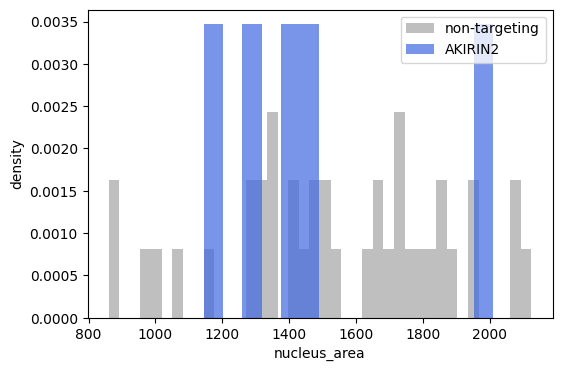

In [13]:
feature = "nucleus_area"
pert = "AKIRIN2"

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(controls[feature], bins=40, alpha=0.5, label="non-targeting", color="grey", density=True)
ax.hist(cells.loc[cells.perturbation_id == pert, feature], bins=15,
        alpha=0.7, label=pert, color="royalblue", density=True)
ax.set_xlabel(feature)
ax.set_ylabel("density")
ax.legend()
plt.show()

## Visualize: volcano plot for one perturbation

Each dot is one feature. The x-axis is the perturbation's effect size; the
y-axis is −log10(FDR). The dashed line is the schema-recommended FDR cutoff.

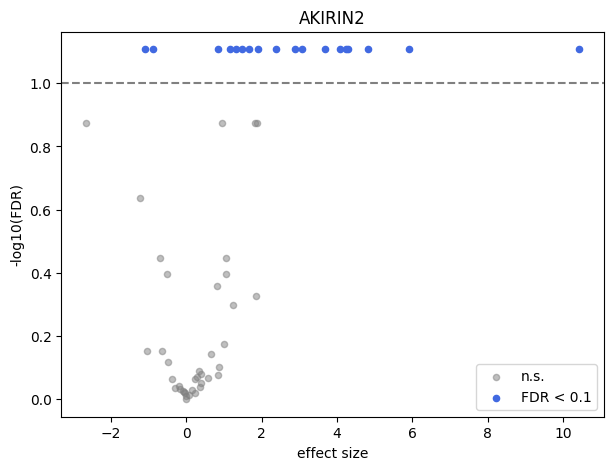

In [14]:
pert = "AKIRIN2"
i = agg.obs_names.get_loc(pert)

effect = agg.X[i]
nlf = agg.layers["neg_log10_fdr"][i]
# The schema FDR cutoff lives at agg.uns["neg_log10_fdr_threshold"]
# (1.301). This test collection's global max neg_log10_fdr is
# 1.108, so we use a lower visualization cutoff here to make the
# significant cluster visible. Use the schema value on real data.
thresh = 1.0
sig_mask = nlf >= thresh

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(effect[~sig_mask], nlf[~sig_mask], s=20, color="grey", alpha=0.5, label="n.s.")
ax.scatter(effect[sig_mask], nlf[sig_mask], s=20, color="royalblue",
           label=f"FDR < {10**-thresh:.2g}")
ax.axhline(thresh, color="grey", linestyle="--")
ax.set_xlabel("effect size")
ax.set_ylabel("-log10(FDR)")
ax.set_title(pert)
ax.legend()
plt.show()

## Visualize: every perturbation for one feature

Flip the volcano around — fix the feature, scatter all perturbations.
Annotate the strongest hits.

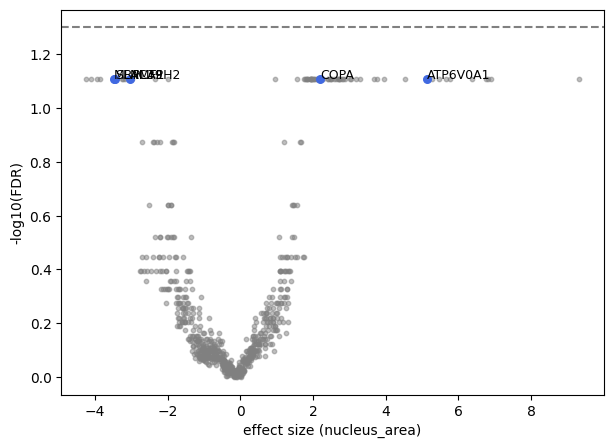

In [15]:
feature = "nucleus_area"
j = agg.var_names.get_loc(feature)

df = pd.DataFrame({
    "perturbation": agg.obs_names,
    "effect_size": agg.X[:, j],
    "neg_log10_fdr": agg.layers["neg_log10_fdr"][:, j],
})

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df.effect_size, df.neg_log10_fdr, s=10, alpha=0.5, color="grey")
ax.axhline(float(agg.uns["neg_log10_fdr_threshold"]), color="grey", linestyle="--")
top = df.nlargest(5, "neg_log10_fdr")
ax.scatter(top.effect_size, top.neg_log10_fdr, s=30, color="royalblue")
for _, r in top.iterrows():
    ax.annotate(r.perturbation, (r.effect_size, r["neg_log10_fdr"]), fontsize=9)
ax.set_xlabel(f"effect size ({feature})")
ax.set_ylabel("-log10(FDR)")
plt.show()

## Visualize: perturbation embedding

`obsm` carries a 2D embedding for the visualization layer. Color by cluster
assignment from `obs`, optionally highlight a perturbation of interest.

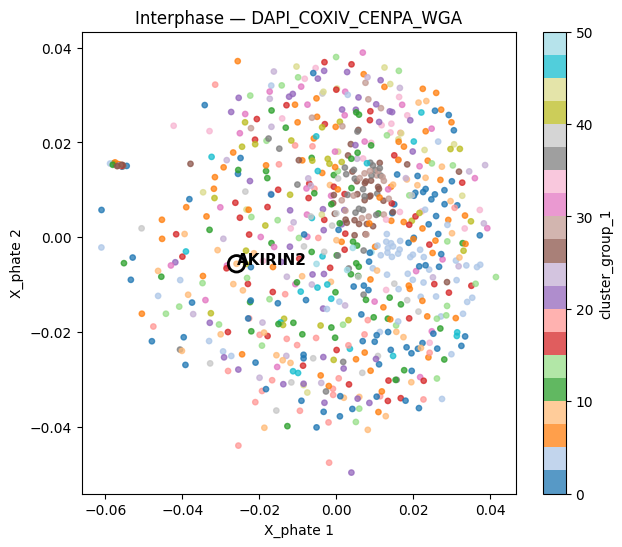

In [16]:
emb_key = agg.uns["default_embedding"]
coords = agg.obsm[emb_key]
clusters = agg.obs["cluster_group_1"].astype(int)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap="tab20", s=15, alpha=0.75)
plt.colorbar(sc, label="cluster_group_1", ax=ax)

pert = "AKIRIN2"
if pert in agg.obs_names:
    p = agg.obsm[emb_key][agg.obs_names.get_loc(pert)]
    ax.scatter(p[0], p[1], s=140, edgecolor="black", facecolor="none", linewidth=2)
    ax.annotate(pert, (p[0], p[1]), fontsize=11, fontweight="bold")

ax.set_xlabel(f"{emb_key} 1")
ax.set_ylabel(f"{emb_key} 2")
ax.set_title(agg.uns["title"])
plt.show()

## Visualize: heatmap of top perturbations × top features

Rank perturbations by total significance, pick the top features the same way,
and plot the effect-size submatrix.

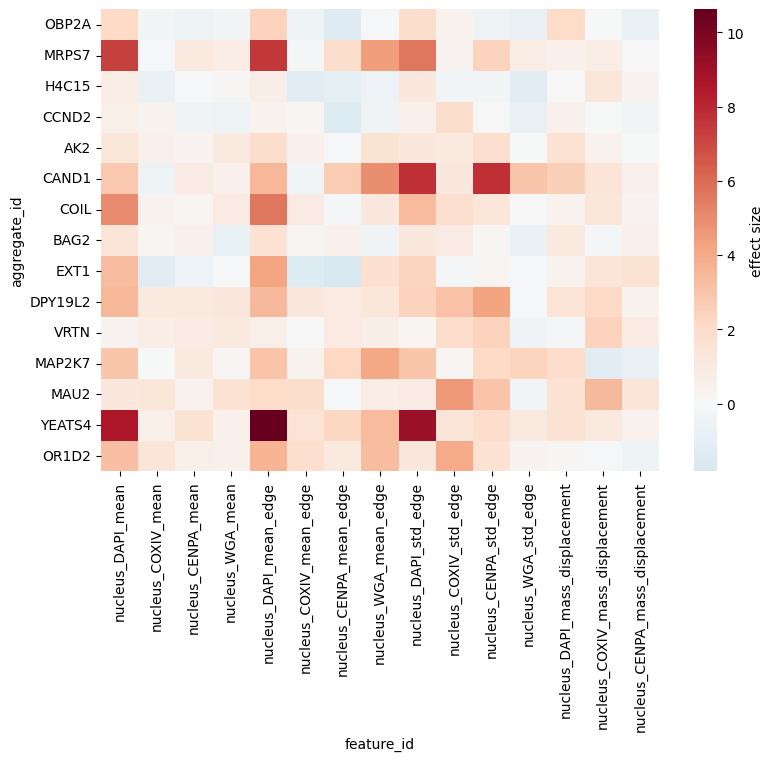

In [17]:
per_pert_score = agg.layers["neg_log10_fdr"].sum(axis=1)
top_perts = pd.Series(per_pert_score, index=agg.obs_names).nlargest(15).index

per_feat_max = agg.layers["neg_log10_fdr"].max(axis=0)
top_feats = pd.Series(per_feat_max, index=agg.var_names).nlargest(15).index

mat = pd.DataFrame(
    agg[top_perts, top_feats].X,
    index=top_perts,
    columns=top_feats,
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(mat, cmap="RdBu_r", center=0, cbar_kws={"label": "effect size"}, ax=ax)
plt.show()

## Visualize: cluster composition

How many perturbations fall in each morphology cluster.

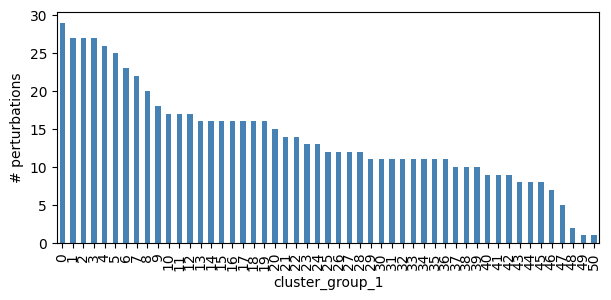

In [18]:
counts = agg.obs.cluster_group_1.astype(int).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 3))
counts.plot.bar(ax=ax, color="steelblue")
ax.set_xlabel("cluster_group_1")
ax.set_ylabel("# perturbations")
plt.show()

## Putting it together: pulling a local copy

The recipes above stream directly from S3 — you can run the whole notebook
without ever putting OPS data on local disk. That's the right pattern for
exploration and one-off analysis.

When you do want a local copy — for example, to run a longer pipeline that
scans the whole `cell_data.parquet` repeatedly, or to work offline — pull the
collection with the CLI **after** you've decided it's the right data:

```bash
# Install once
pip install biohub-data-cli

# Preview the size budget
ops-data download collection <collection-id> --dry-run

# Download the collection to ./data
ops-data download collection <collection-id> -o ./data -y
```

Full reference:
[**CLI Reference**](https://github.com/chanzuckerberg/ops-schema/blob/main/docs/cli/index.md).

The helper below pulls every artifact under a downloaded OPS collection
directory into a single nested dict — `cell_data` per experiment,
`aggregated_data` per visualization — so subsequent scripts can grab a single
handle and go. It expects the layout `ops-data download collection` writes:

```
{collection_root}/
├── collection_metadata.yaml
└── {screen_name}/                  # one or more
    ├── cell_data.parquet
    └── visualizations/
        └── {visualization_id}/
            └── aggregated_data.h5ad
```

The Brieflow test collection uses a flat layout (no `{screen_name}/`
subdirectory); the function falls back to that when the standard layout is
absent.

> **Status (2026-05):** The CLI's catalog backend is stubbed in v0.1.1, so
> real collection IDs raise `NotImplementedError`. The streaming flow above
> works today against any publicly hosted OPS collection; the download flow
> here will start working out of the box once the backend is wired up.


In [19]:
def load_collection(root):
    """Load every schema-conformant artifact under an OPS collection directory."""
    root = Path(root)
    out = {"experiments": {}}

    cm = root / "collection_metadata.yaml"
    if cm.exists():
        with open(cm) as fh:
            out["collection_metadata"] = yaml.safe_load(fh)

    # Standard layout: one subdirectory per experiment
    for cd in root.glob("*/cell_data.parquet"):
        screen_dir = cd.parent
        viz_dir = screen_dir / "visualizations"
        out["experiments"][screen_dir.name] = {
            "cell_data": pd.read_parquet(cd),
            "visualizations": {
                v.name: ad.read_h5ad(v / "aggregated_data.h5ad")
                for v in (viz_dir.glob("*") if viz_dir.exists() else [])
                if (v / "aggregated_data.h5ad").exists()
            },
        }

    # Flat-layout fallback (e.g., the Brieflow test collection)
    if not out["experiments"] and (root / "cell_data.parquet").exists():
        out["experiments"]["."] = {
            "cell_data": pd.read_parquet(root / "cell_data.parquet"),
            "visualizations": (
                {"default": ad.read_h5ad(root / "aggregated_data.h5ad")}
                if (root / "aggregated_data.h5ad").exists() else {}
            ),
        }

    return out


loaded = load_collection(COLLECTION)
{
    "metadata": loaded.get("collection_metadata"),
    "experiments": {
        name: {
            "cell_data_shape": exp["cell_data"].shape,
            "visualizations": {v: a.shape for v, a in exp["visualizations"].items()},
        }
        for name, exp in loaded["experiments"].items()
    },
}

{'metadata': {'collection': {'title': 'Brieflow Test Collection',
   'publication_doi': None}},
 'experiments': {'.': {'cell_data_shape': (1372, 1696),
   'visualizations': {'default': (709, 76)}}}}